# Matplotlib 1 - Foundations

> **MLCourse · Data Science Foundations · 03_matplotlib**

Matplotlib turns arrays into pictures. This notebook builds your mental model of
HOW it thinks (figures, axes, artists), then walks through every core chart type
you will use daily.

### What you'll learn
- Figure vs Axes vs Axis - the anatomy of every plot
- Line plots with full styling control (colors, dashes, markers)
- Scatter, bar (grouped & stacked), histogram, pie, box plots
- Titles, labels, legends, grids, limits and ticks
- Figure sizing, layout engines, and saving publication-quality files

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt   # the plotting interface
import numpy as np                # data generation
import pandas as pd               # tabular convenience

np.random.seed(42)                # reproducible "random" data

plt.rcParams["figure.dpi"] = 100  # slightly crisper inline figures

### 1. Anatomy - how Matplotlib sees a plot

Two ideas explain 90% of Matplotlib:

| Object | What it is |
|---|---|
| **Figure** | the whole canvas/window (can hold many Axes) |
| **Axes** | ONE plot area with its own x/y axis (despite the name, it's *the plot*) |
| **Axis** | the number line objects (`ax.xaxis`, `ax.yaxis`) that draw ticks |
| **Artist** | everything visible: lines, text, ticks, legends… |

### Draw an annotated diagram of the anatomy itself:


In [ ]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])          # manual placement: [left,bottom,w,h]

x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x))

# Point at each anatomical part with arrows:
ax.annotate("Figure = canvas", xy=(0.02, 0.97), xycoords="axes fraction",
            fontsize=11, color="gray")
ax.annotate("Title", xy=(0.5, 1.02), xytext=(0.35, 1.18), xycoords="axes fraction",
            textcoords="axes fraction", arrowprops=dict(arrowstyle="->"))
ax.annotate("y-axis (Axis object)", xy=(-0.02, 0.5), xytext=(-0.28, 0.75),
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->"))
ax.annotate("x-axis (Axis object)", xy=(0.5, -0.04), xytext=(0.55, -0.22),
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->"))
ax.annotate("spine (border line)", xy=(0.995, 0.5), xytext=(0.72, 0.85),
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->"))
ax.set_title("Anatomy of a plot")
fig.subplots_adjust(top=0.82, left=0.24, bottom=0.22)   # make room for labels
plt.show()


> 💡 **Pro tip:** remember it as **"a Figure holds one or more Axes; each Axes
has two Axis objects"**. Almost every confusion in Matplotlib comes from mixing
up Axes (the plot) with Axis (the number line).

### 2. Your first plot - and what pyplot does


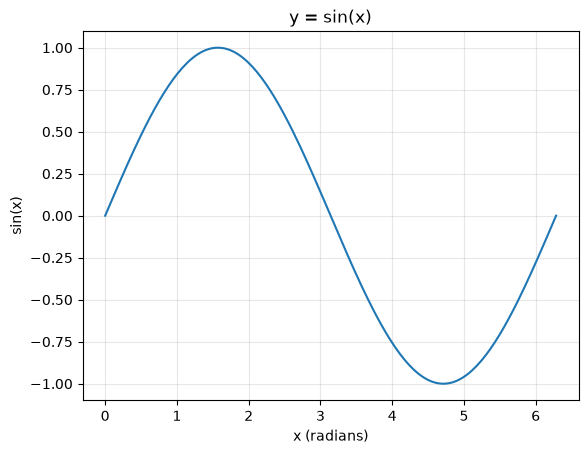

In [3]:
xs = np.linspace(0, 2 * np.pi, 200)     # 200 points from 0 to 2π

plt.plot(xs, np.sin(xs))                # pyplot finds-or-creates figure+axes for you
plt.title("y = sin(x)")
plt.xlabel("x (radians)")
plt.ylabel("sin(x)")
plt.grid(alpha=0.3)                     # subtle grid helps read values
plt.show()                              # renders and closes the loop

# `pyplot` keeps a hidden "current figure" - convenient for quick exploration,
# but we will graduate to explicit Axes below for anything serious.

### 3. Line plots - full styling control

Every visual property is a parameter: color, linestyle, linewidth, marker, alpha.

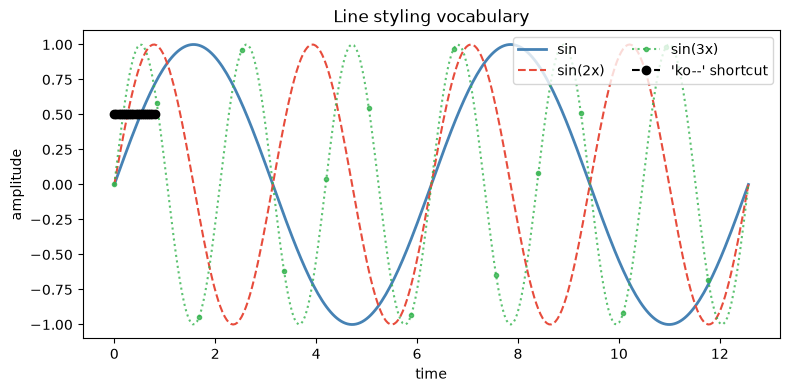

In [4]:
t = np.linspace(0, 4 * np.pi, 300)

fig, ax = plt.subplots(figsize=(9, 4))          # THE idiom: returns Figure + one Axes

ax.plot(t, np.sin(t), color="steelblue", lw=2, label="sin")
ax.plot(t, np.sin(2*t), color="#e74c3c",        # hex colors work anywhere
        ls="--", lw=1.5, label="sin(2x)")
ax.plot(t, np.sin(3*t), color=(0.2, 0.7, 0.3),  # RGB tuple, 0-1 floats
        ls=":", marker="o", ms=3, markevery=20, # dotted + marker every 20th point
        alpha=0.8, label="sin(3x)")
ax.plot(t[:20], t[:20] ** 0 / 2, "ko--",        # fmt shortcut string: marker+color+line
        label="'ko--' shortcut")                # k=black, o=circle, --=dashed

ax.legend(loc="upper right", ncols=2, frameon=True)   # 2 columns, framed box
ax.set_title("Line styling vocabulary")
ax.set_xlabel("time")
ax.set_ylabel("amplitude")
plt.show()

Style cheat-sheet: colors → `"steelblue"`, `"#e74c3c"`, `(r,g,b)` ·
linestyles → `-` solid, `--` dashed, `:` dotted, `-.` dashdot ·
markers → `o s ^ * D` · shortcut strings → `"[marker][color][line]"` e.g. `"ro-"`.

### 4. Scatter plots - relationships between two variables


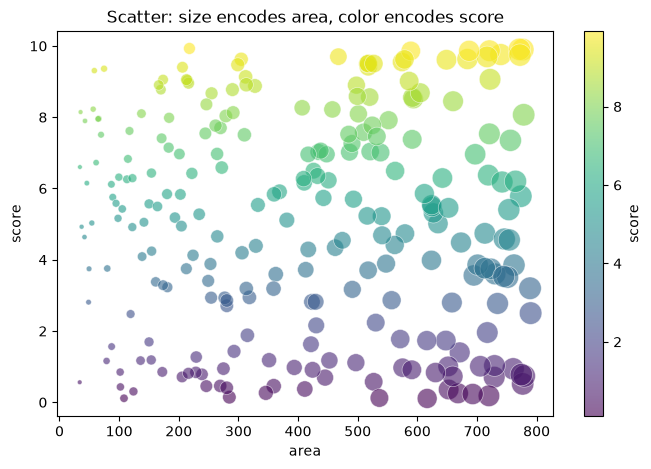

In [5]:
n = 250
area  = np.random.uniform(30, 800, n)      # bubble sizes
score = np.random.uniform(0, 10, n)        # drives color

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    area, score,
    s=area / 3,                            # size per point (points²)
    c=score,                               # color mapped from data...
    cmap="viridis",                        # ...through this colormap
    alpha=0.6,                             # transparency reveals density
    edgecolors="white", linewidths=0.5,
)
fig.colorbar(sc, label="score")            # legend for the color mapping
ax.set_title("Scatter: size encodes area, color encodes score")
ax.set_xlabel("area")
ax.set_ylabel("score")
plt.show()

> ⚠️ **Common pitfall:** without `alpha`, overlapping points hide thousands of
observations behind one dot. When scatter looks like a blob, add transparency
or switch to a 2-D histogram (next notebook).

### 5. Bar charts - comparing categories


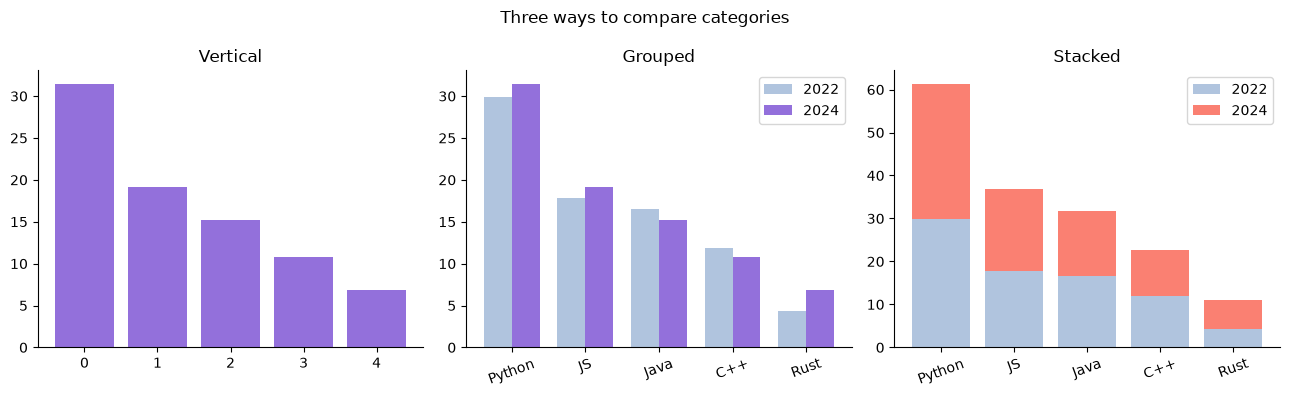

In [6]:
categories = ["Python", "JS", "Java", "C++", "Rust"]
pop_2022 = [29.9, 17.8, 16.5, 11.9, 4.3]
pop_2024 = [31.5, 19.1, 15.2, 10.8, 6.8]

xpos = np.arange(len(categories))           # numeric positions for categories

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# --- vertical bars ---
axes[0].bar(xpos, pop_2024, color="mediumpurple")
axes[0].set_title("Vertical")

# --- GROUPED: offset each year's bars around the category position ---
w = 0.38                                     # bar width
axes[1].bar(xpos - w/2, pop_2022, w, label="2022", color="lightsteelblue")
axes[1].bar(xpos + w/2, pop_2024, w, label="2024", color="mediumpurple")
axes[1].set_xticks(xpos, categories, rotation=20)
axes[1].legend()
axes[1].set_title("Grouped")

# --- STACKED: second series starts where first ends (bottom=) ---
axes[2].bar(xpos, pop_2022, label="2022", color="lightsteelblue")
axes[2].bar(xpos, pop_2024, bottom=pop_2022, label="2024", color="salmon")
axes[2].set_xticks(xpos, categories, rotation=20)
axes[2].legend()
axes[2].set_title("Stacked")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)    # cleaner look
fig.suptitle("Three ways to compare categories")
fig.tight_layout()
plt.show()

### 6. Histograms - the shape of ONE variable


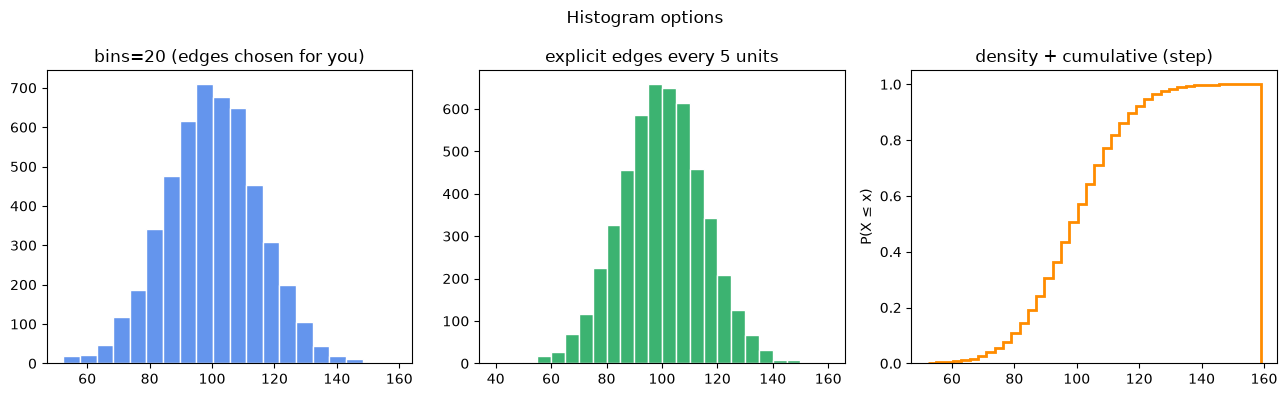

In [7]:
samples = np.random.normal(loc=100, scale=15, size=5000)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].hist(samples, bins=20, color="cornflowerblue", edgecolor="white")
axes[0].set_title(f"bins=20 (edges chosen for you)")

axes[1].hist(samples, bins=np.arange(40, 165, 5),  # explicit bin edges
             color="mediumseagreen", edgecolor="white")
axes[1].set_title("explicit edges every 5 units")

# density=True converts counts -> probability density (integrates to 1);
# cumulative=True flips the story to 'how many BELOW this value'.
axes[2].hist(samples, bins=40, density=True, cumulative=True,
             histtype="step", lw=2, color="darkorange")
axes[2].set_title("density + cumulative (step)")
axes[2].set_ylabel("P(X ≤ x)")

fig.suptitle("Histogram options")
fig.tight_layout()
plt.show()

> 💡 **Pro tip:** always draw histograms with `edgecolor="white"` - adjacent
bins become visually separable instead of merging into one block.

### 7. Pie charts - parts of a whole (with honesty rules)


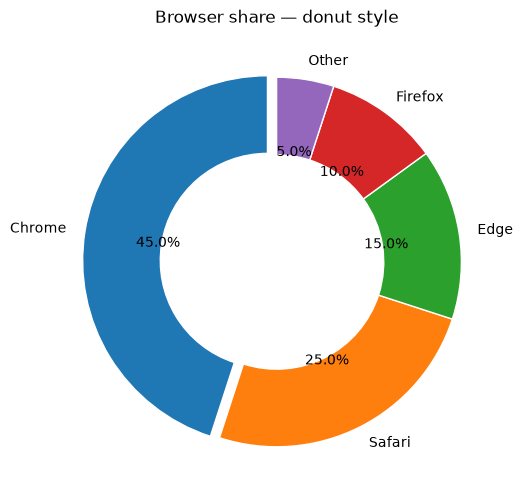

In [8]:
shares = [45, 25, 15, 10, 5]
labels = ["Chrome", "Safari", "Edge", "Firefox", "Other"]
explode = [0.05, 0, 0, 0, 0]                  # pull Chrome out slightly

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    shares,
    labels=labels,
    autopct="%1.1f%%",                        # format percentages on slices
    explode=explode,
    startangle=90,                            # rotate so first slice starts at top
    wedgeprops=dict(width=0.42, edgecolor="white"),  # width < 1 => DONUT
)
ax.set_title("Browser share - donut style")
plt.show()

# Honest critique: humans judge ANGLES poorly. Use bars when precise comparison
# matters; keep pies to ≤5 slices with clearly dominant values.

### 8. Box plots - five-number summaries & outliers


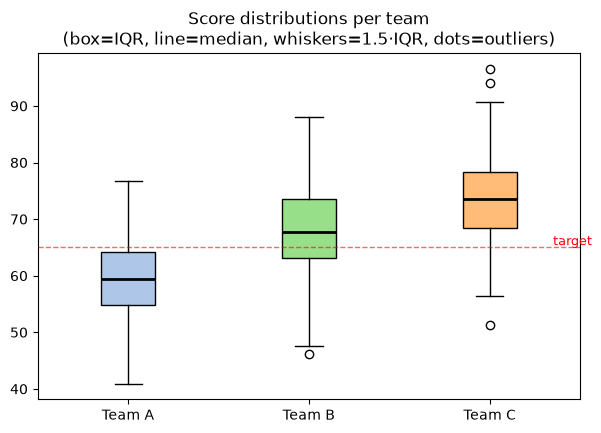

In [9]:
groups = [np.random.normal(mu, 8, 120) for mu in (60, 68, 74)]
names  = ["Team A", "Team B", "Team C"]

fig, ax = plt.subplots(figsize=(7, 4.5))
bp = ax.boxplot(
    groups,
    tick_labels=names,                 # matplotlib ≥3.9 name; older: labels=
    patch_artist=True,                 # allows filling boxes with color
    medianprops=dict(color="black", lw=2),
)
for patch, color in zip(bp["boxes"], ["#aec7e8", "#98df8a", "#ffbb78"]):
    patch.set_facecolor(color)

ax.axhline(65, color="red", ls="--", lw=1, alpha=0.6)   # target reference line
ax.text(3.35, 65.4, "target", color="red", fontsize=9)
ax.set_title("Score distributions per team\n(box=IQR, line=median, whiskers=1.5·IQR, dots=outliers)")
plt.show()

### 9. Labels, titles, grids, limits, ticks - polish toolkit


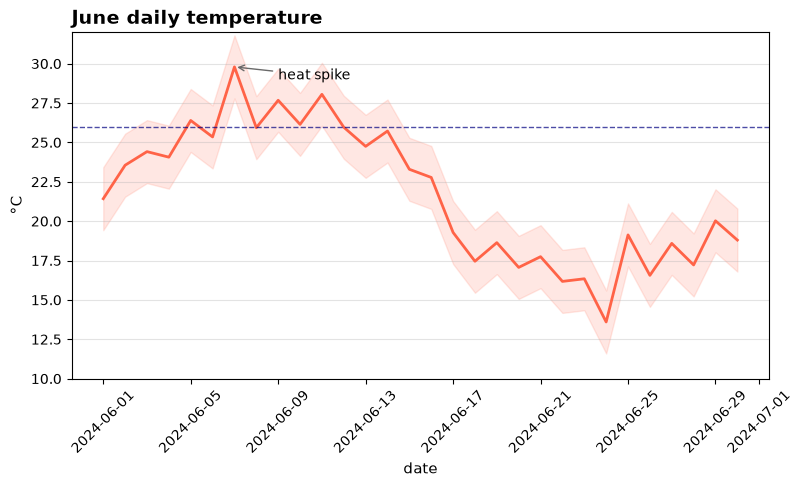

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
days = pd.date_range("2024-06-01", periods=30)
temp = 22 + 6 * np.sin(np.arange(30) / 30 * 2 * np.pi) + np.random.normal(0, 1.5, 30)

ax.plot(days, temp, color="tomato", lw=2)
ax.fill_between(days, temp - 2, temp + 2, color="tomato", alpha=0.15)  # uncertainty band

ax.set_title("June daily temperature", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("date", fontsize=11)
ax.set_ylabel("°C", fontsize=11)
ax.set_ylim(10, 32)                                   # force y-range
ax.grid(axis="y", which="major", alpha=0.35)          # horizontal grid only
ax.tick_params(axis="x", rotation=45)                 # readable date labels

ax.axhline(26, color="navy", ls="--", lw=1, alpha=0.7)
ax.annotate("heat spike", xy=(days[np.argmax(temp)], temp.max()),
            xytext=(days[8], 29),
            arrowprops=dict(arrowstyle="->", color="dimgray"))
plt.show()

### 10. Figure control & saving


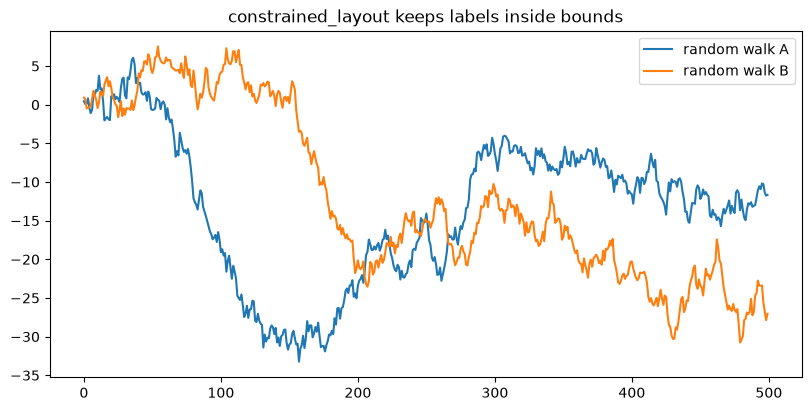

saved: my_first_chart.png


In [11]:
# figsize is in INCHES; dpi multiplies pixels. 8×4 @150dpi = 1200×600 px.
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)  # auto-tidy spacing
ax.plot(np.cumsum(np.random.randn(500)), label="random walk A")
ax.plot(np.cumsum(np.random.randn(500)), label="random walk B")
ax.set_title("constrained_layout keeps labels inside bounds")
ax.legend()
plt.show()

out_path = "my_first_chart.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")   # bbox trims whitespace
print("saved:", out_path)
# Formats: .png (raster, reports/slides) · .svg/.pdf (vector, papers - infinite zoom)

> ⚠️ **Common pitfall:** `savefig` AFTER `plt.show()` may save an empty image -
show() closes the figure. Call savefig BEFORE show, or keep using the `fig`
object directly.

### Summary & key takeaways

- **Figure** = canvas, **Axes** = one plot, **Axis** = number line. Say it until
  it sticks.
- `fig, ax = plt.subplots()` is the professional idiom - use `ax.method(...)`.
- Line styling = color + linestyle + linewidth + marker + alpha; shortcuts like
  `"ro--"` compress them.
- Grouped bars: offset positions; stacked bars: `bottom=`; both need `xticks`
  back at category names.
- Histograms need deliberate `bins`; `density=True` makes series comparable;
  white edges improve readability.
- Pies are fine for ≤5 dominant slices; donut via `wedgeprops(width=...)`.
- Box plots summarize distribution + outliers; combine with reference lines.
- Polish = titles/labels/grid/limits/ticks/annotations - cheap effort, huge clarity.
- Save with `dpi=200+, bbox_inches="tight"`; choose SVG/PDF when scaling matters.